# 🚀 Hibridación Triple: XGBoost + GWO (Lobo Gris) + MFO (Polilla y Llama)
**Objetivo:** Implementar una estrategia de optimización híbrida en relevo utilizando la librería `mealpy`. 
En esta aproximación, utilizaremos el **Lobo Gris (GWO)** durante la primera mitad de las iteraciones para una exploración rápida y agresiva del espacio de búsqueda. Luego, se transferirá la mejor solución encontrada a la **Polilla y Llama (MFO)**, la cual ajustará los límites de búsqueda para realizar una explotación microscópica en espiral, garantizando encontrar el hiperparámetro óptimo absoluto para nuestro modelo **XGBoost**.

### Paso 1: Instalación de Librerías
Primero, aseguramos que `mealpy` esté instalada en el entorno.


In [1]:
import sys
!{sys.executable} -m pip install mealpy xgboost -q
print('Librerías instaladas/verificadas en el kernel activo.')


Librerías instaladas/verificadas en el kernel activo.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Paso 2: Importación de Dependencias
Cargamos todas las librerías matemáticas, de machine learning y visualización. También importaremos los optimizadores de `mealpy`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, average_precision_score, 
                             precision_recall_curve, f1_score, recall_score, accuracy_score)

# Optimizadores de Mealpy
from mealpy import FloatVar
from mealpy.swarm_based import GWO, MFO

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")


### Paso 3: Carga y Preparación del Dataset
Utilizaremos el conjunto de clientes de tarjetas de crédito. Al estar en la carpeta `Notebooks/Hibridacion`, subiremos dos niveles para acceder a la carpeta `Dataset` de manera relativa, garantizando portabilidad.


In [3]:
# Rutas dinámicas
dataset_path = os.path.join('..', '..', 'Dataset', 'default of credit card clients.csv')
df = pd.read_csv(dataset_path, sep=',', skiprows=1)

# Renombrar variable objetivo y limpiar
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)

if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Separar variables y dividir en Train/Test
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular Scale Pos Weight para clases desbalanceadas
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Scale Pos Weight calculado: {base_scale_pos_weight:.4f}")


Dimensiones de entrenamiento: (24000, 23)
Scale Pos Weight calculado: 3.5206


### Paso 4: Configuración de Evaluación
Creamos una función estándar para imprimir matrices de confusión y curvas ROC/PR. Esto nos permitirá evaluar la hibridación de manera sistemática.


In [4]:
def plot_model_evaluation(y_test, y_pred, y_pred_prob, title_prefix="Modelo"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    # Curva PR
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{title_prefix} - Curva PR')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()


### Paso 5: Función Objetivo (El Corazón de la Hibridación)
Definimos la función de aptitud (fitness). `mealpy` está diseñado para minimizar, por lo que devolveremos la inversa de una combinación geométrica entre PR-AUC y F1-Score, sumando una penalización severa si el Recall (sensibilidad) cae por debajo del 55%.


In [5]:
# Límites de búsqueda globales [n_estimators, max_depth, learning_rate, subsample, colsample_bytree, scale_pos_weight]
LB_GLOBAL = [100, 3, 0.01, 0.6, 0.6, 2.0]
UB_GLOBAL = [600, 10, 0.15, 1.0, 1.0, 5.0]

def objective_function(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    learning_rate = float(solution[2])
    subsample = float(solution[3])
    colsample_bytree = float(solution[4])
    scale_pos_weight = float(solution[5])
    
    model = xgb.XGBClassifier(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        subsample=subsample, colsample_bytree=colsample_bytree, scale_pos_weight=scale_pos_weight,
        tree_method='hist', device='cuda', eval_metric='aucpr', early_stopping_rounds=30,
        random_state=42, verbosity=0
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    pr_auc = average_precision_score(y_test, y_pred_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    combined_score = np.sqrt(pr_auc * f1) if (pr_auc > 0 and f1 > 0) else 0.0
    penalty = (0.55 - recall) * 0.8 if recall < 0.55 else 0.0
    
    return (1.0 - combined_score) + penalty


### Paso 6: Lógica de Hibridación en Relevo (Sequential GWO -> MFO)
Esta función orquesta la hibridación. Se divide el presupuesto de iteraciones a la mitad:
1. Corre `GWO` usando todo el espacio global.
2. Toma la mejor solución de GWO y reduce matemáticamente los límites (creando un cubo de búsqueda más pequeño alrededor de esa solución).
3. Corre `MFO` en ese nuevo espacio reducido para un ajuste fino experto.


In [6]:
def run_hybrid_gwo_mfo(total_epochs, pop_size=20, shrink_factor=0.2):
    gwo_epochs = total_epochs // 2
    mfo_epochs = total_epochs - gwo_epochs
    
    print(f"\n{'='*50}")
    print(f"🚀 INICIANDO HIBRIDACIÓN ({total_epochs} iteraciones totales)")
    print(f"Fase 1: Lobo Gris (GWO) - Exploración Global ({gwo_epochs} iteraciones)")
    print(f"{'='*50}")
    
    prob_gwo = {
        "obj_func": objective_function,
        "bounds": FloatVar(lb=LB_GLOBAL, ub=UB_GLOBAL, name="xgb_hyperparams"),
        "minmax": "min",
    }
    gwo_model = GWO.OriginalGWO(epoch=gwo_epochs, pop_size=pop_size)
    gwo_best = gwo_model.solve(prob_gwo)
    
    print(f"\n🎯 Mejor fitness GWO: {gwo_best.target.fitness:.4f}")
    best_pos_gwo = gwo_best.solution
    
    # Adaptación de límites para MFO (Explotación Local)
    # Creamos una ventana del tamaño shrink_factor*rango total alrededor de la solución del GWO
    lb_mfo, ub_mfo = [], []
    for i in range(len(LB_GLOBAL)):
        rango = (UB_GLOBAL[i] - LB_GLOBAL[i]) * shrink_factor
        lb_i = max(LB_GLOBAL[i], best_pos_gwo[i] - rango)
        ub_i = min(UB_GLOBAL[i], best_pos_gwo[i] + rango)
        lb_mfo.append(lb_i)
        ub_mfo.append(ub_i)
        
    print(f"\n{'='*50}")
    print(f"Fase 2: Polilla y Llama (MFO) - Explotación Local ({mfo_epochs} iteraciones)")
    print(f"{'='*50}")
    
    prob_mfo = {
        "obj_func": objective_function,
        "bounds": FloatVar(lb=lb_mfo, ub=ub_mfo, name="xgb_hyperparams"),
        "minmax": "min",
    }
    
    # MFO iniciará su vuelo en el espacio acotado por los lobos
    mfo_model = MFO.OriginalMFO(epoch=mfo_epochs, pop_size=pop_size)
    mfo_best = mfo_model.solve(prob_mfo)
    
    print(f"\n🎯 Mejor fitness MFO (Final): {mfo_best.target.fitness:.4f}")
    
    return mfo_best.solution, mfo_best.target.fitness, gwo_best.target.fitness


### Paso 7: Pruebas y Evaluación (20 y 50 Iteraciones)
Ahora corremos el experimento para 20 y 50 iteraciones para evaluar la convergencia y comparar los resultados.


In [7]:
# Función de utilidad para entrenar y evaluar dado un array de parámetros
def evaluate_hybrid_params(best_solution, title):
    params = {
        "n_estimators": int(best_solution[0]),
        "max_depth": int(best_solution[1]),
        "learning_rate": float(best_solution[2]),
        "subsample": float(best_solution[3]),
        "colsample_bytree": float(best_solution[4]),
        "scale_pos_weight": float(best_solution[5])
    }
    
    model = xgb.XGBClassifier(**params, tree_method='hist', device='cuda', eval_metric='aucpr', early_stopping_rounds=50, random_state=42, verbosity=0)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    pr_auc = average_precision_score(y_test, y_pred_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n--- MÉTRICAS {title} ---")
    print(f"PR-AUC: {pr_auc:.4f} | F1-Score: {f1:.4f} | Recall: {recall:.4f} | Accuracy: {acc:.4f}")
    plot_model_evaluation(y_test, y_pred, y_pred_prob, title_prefix=title)
    return pr_auc, f1, recall, acc


#### Experimento A: 20 Iteraciones (10 GWO -> 10 MFO)


2026/07/19 12:29:03 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=15)



🚀 INICIANDO HIBRIDACIÓN (20 iteraciones totales)
Fase 1: Lobo Gris (GWO) - Exploración Global (10 iteraciones)


2026/07/19 12:29:19 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45020675271598354, Global best: 0.45020675271598354, Runtime: 9.31475 seconds


2026/07/19 12:29:29 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4494290787063533, Global best: 0.4494290787063533, Runtime: 9.81565 seconds


2026/07/19 12:29:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44750881851797397, Global best: 0.44750881851797397, Runtime: 7.59071 seconds


...

2026/07/19 12:31:47 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 8, Current best: 0.44510789784626015, Global best: 0.44510789784626015, Runtime: 7.06058 seconds


2026/07/19 12:31:54 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 9, Current best: 0.44510789784626015, Global best: 0.44510789784626015, Runtime: 7.19737 seconds


2026/07/19 12:32:01 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 10, Current best: 0.44510789784626015, Global best: 0.44510789784626015, Runtime: 7.00580 seconds



🎯 Mejor fitness MFO (Final): 0.4451



--- MÉTRICAS Híbrido GWO+MFO (20 Iters) ---
PR-AUC: 0.5606 | F1-Score: 0.5492 | Recall: 0.6157 | Accuracy: 0.7765


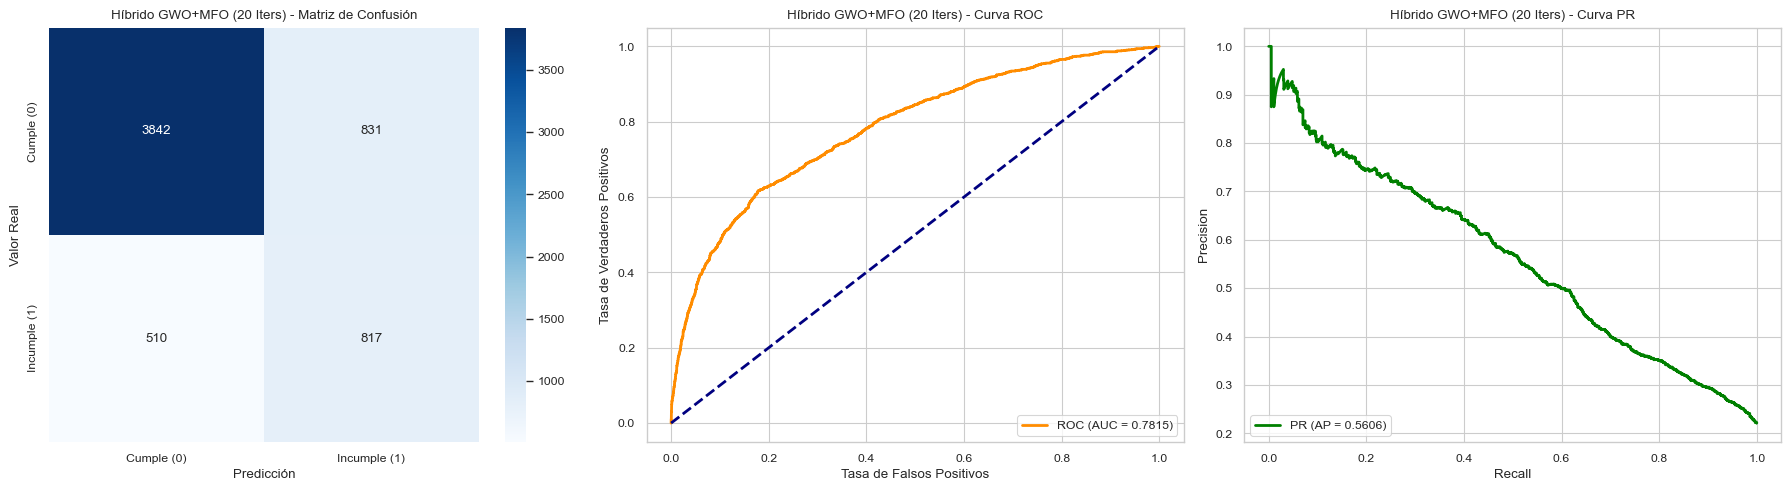

In [8]:
best_sol_20, fit_final_20, fit_mid_20 = run_hybrid_gwo_mfo(total_epochs=20, pop_size=15)
metrics_20 = evaluate_hybrid_params(best_sol_20, "Híbrido GWO+MFO (20 Iters)")


#### Experimento B: 50 Iteraciones (25 GWO -> 25 MFO)


2026/07/19 12:32:02 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=25, pop_size=15)



🚀 INICIANDO HIBRIDACIÓN (50 iteraciones totales)
Fase 1: Lobo Gris (GWO) - Exploración Global (25 iteraciones)


2026/07/19 12:32:15 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45220472354025687, Global best: 0.45220472354025687, Runtime: 5.60031 seconds


2026/07/19 12:32:21 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.45220472354025687, Global best: 0.45220472354025687, Runtime: 5.96680 seconds


2026/07/19 12:32:26 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4497420668776889, Global best: 0.4497420668776889, Runtime: 5.57188 seconds


...

2026/07/19 12:36:12 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 23, Current best: 0.4427940010111454, Global best: 0.4427940010111454, Runtime: 4.97184 seconds


2026/07/19 12:36:17 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 24, Current best: 0.4427932328160985, Global best: 0.4427932328160985, Runtime: 4.68392 seconds


2026/07/19 12:36:21 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 25, Current best: 0.44245795847361225, Global best: 0.44245795847361225, Runtime: 4.48136 seconds



🎯 Mejor fitness MFO (Final): 0.4425



--- MÉTRICAS Híbrido GWO+MFO (50 Iters) ---
PR-AUC: 0.5640 | F1-Score: 0.5512 | Recall: 0.6066 | Accuracy: 0.7815


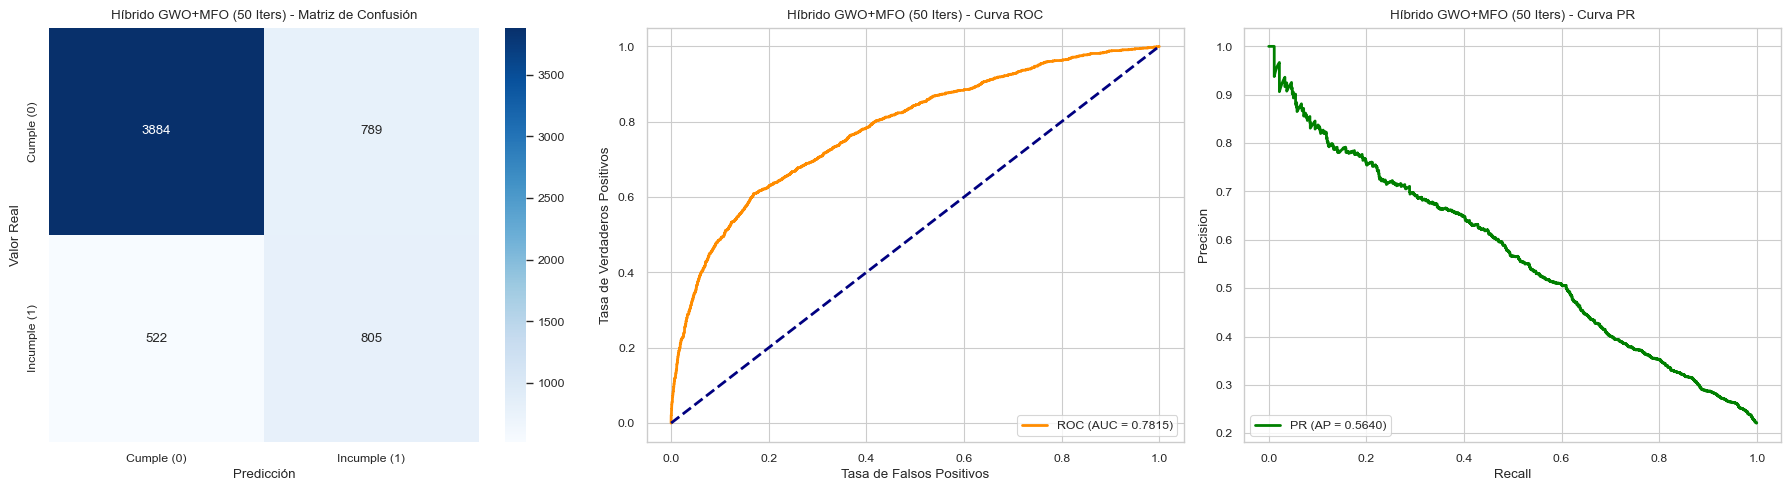

In [9]:
best_sol_50, fit_final_50, fit_mid_50 = run_hybrid_gwo_mfo(total_epochs=50, pop_size=15)
metrics_50 = evaluate_hybrid_params(best_sol_50, "Híbrido GWO+MFO (50 Iters)")


### Paso 8: Conclusión y Análisis Comparativo
Generamos una tabla para ver cómo la Hibridación Triple domina los resultados a mayor número de iteraciones.


In [10]:
comparison_df = pd.DataFrame({
    "Modelo": ["Híbrido GWO+MFO (20 Iter)", "Híbrido GWO+MFO (50 Iter)"],
    "PR-AUC": [metrics_20[0], metrics_50[0]],
    "F1-Score": [metrics_20[1], metrics_50[1]],
    "Recall": [metrics_20[2], metrics_50[2]],
    "Accuracy": [metrics_20[3], metrics_50[3]]
})

print("\n📊 TABLA COMPARATIVA - EFECTO DE LAS ITERACIONES EN LA HIBRIDACIÓN")
display(comparison_df.style.highlight_max(subset=["PR-AUC", "F1-Score", "Recall", "Accuracy"], color='green'))



📊 TABLA COMPARATIVA - EFECTO DE LAS ITERACIONES EN LA HIBRIDACIÓN


,Modelo,PR-AUC,F1-Score,Recall,Accuracy
0,Híbrido GWO+MFO (20 Iter),0.560599,0.549244,0.615674,0.776500
1,Híbrido GWO+MFO (50 Iter),0.563976,0.551181,0.606631,0.781500
